# 10 - Pipeline complet de controle de conformite

**Objectif :** integrer tout ce qui a ete valide (segmentation U-Net, mesure a
l'echelle, appariement de conformite) en UN SEUL pipeline utilisable :

```
PDF trace -> segmentation U-Net -> detection des pieces -> mesure en cm
          -> appariement a la table de reference -> verdict PASS/FAIL par piece
```

**Entree :** un fichier PDF de trace (un des 4 connus, ou un nouveau).
**Sortie :** un rapport structure (tableau + JSON) avec, pour chaque piece
detectee, ses dimensions mesurees, la piece de reference la plus proche,
l'erreur en cm, et le verdict de conformite (tolerance ±3cm) - plus la
liste des pieces reference JAMAIS retrouvees (manquantes) et des
detections qui ne correspondent a aucune reference (inattendues).

**Limite importante a connaitre :** les checkpoints U-Net disponibles ont
chacun ete entraines en excluant UN des 4 traces (validation
leave-one-trace-out, Phase 3). Pour verifier un des 4 traces connus, ce
notebook utilise automatiquement le checkpoint qui ne l'a PAS vu pendant
l'entrainement (coherent, pas de fuite de donnees). Pour un CINQUIEME trace
totalement nouveau, il faudrait un modele final entraine sur les 4 traces
complets (evoque dans les prochaines etapes du notebook 06) - non
disponible ici, a construire si besoin.

In [1]:
import sys
sys.path.append('../src/segmentation')

import json
import time
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from model import build_model
from dataset import IMAGENET_MEAN, IMAGENET_STD

try:
    import fitz  # PyMuPDF
except ImportError:
    raise ImportError("PyMuPDF manquant. Installer avec : pip install pymupdf")

## 0. Configuration

In [2]:
CHECKPOINTS_DIR = '../models/saved'
RESULTS_DIR = '../data/results'
ANNOTATIONS_DIR = '../data/processed'
REFERENCE_TABLE_PATH = '../data/processed/reference_dimensions.json'
TRACEES_PDF_DIR = '../data/raw/reference'

TOLERANCE_CM = 3.0
MIN_AREA_CM2 = 10.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRACEES_CONNUS = ["Tracee1", "Tracee2", "Tracee3", "Tracee4"]

with open(REFERENCE_TABLE_PATH) as f:
    table_reference = json.load(f)

print(f"Device : {DEVICE}")
print(f"Table de reference chargee : {len(table_reference)} modeles ({list(table_reference.keys())})")

Device : cuda
Table de reference chargee : 4 modeles (['Tracee1', 'Tracee2', 'Tracee3', 'Tracee4'])


## 1. Fonctions du pipeline

Reprises et validees dans le notebook 09 (meilleure configuration trouvee :
tuiles chevauchantes stride=128, PAS de fermeture morphologique - degradait
les resultats).

In [3]:
def find_pdf_for_tracee(tracee, pdf_dir=TRACEES_PDF_DIR):
    pdf_dir = Path(pdf_dir)
    if not pdf_dir.exists():
        return None
    for c in sorted(pdf_dir.glob("*.pdf")):
        if tracee.lower() in c.stem.lower():
            return c
    return None


def get_scale_and_target_size(tracee, pdf_path):
    """Pour un des 4 traces connus : reutilise la taille/echelle exacte de
    la Phase 1 (calibree par carte physique). Pour un trace inconnu : calcule
    l'echelle directement depuis la geometrie vectorielle du PDF (1:1 connu),
    en ciblant ~4000px sur le plus grand cote (coherent avec les traces
    d'entrainement)."""
    annot_path = Path(ANNOTATIONS_DIR) / f"{tracee}_annotations.json"
    bench_path = Path(RESULTS_DIR) / "01_baseline_benchmark.json"
    if annot_path.exists() and bench_path.exists():
        with open(annot_path) as f:
            annot = json.load(f)
        with open(bench_path) as f:
            bench = json.load(f)[tracee]
        w_px, h_px = annot["image_original_size_px"]
        w_cm, h_cm = bench["taille_physique_reelle_cm"]
        scale_cm_par_px = ((w_cm / w_px) + (h_cm / h_px)) / 2
        return w_px, h_px, scale_cm_par_px

    # trace inconnu : PDF vectoriel 1:1, on cible ~4000px sur le plus grand cote
    doc = fitz.open(pdf_path)
    page_w_pt, page_h_pt = doc[0].rect.width, doc[0].rect.height
    doc.close()
    target_long_side = 4000
    if page_w_pt >= page_h_pt:
        w_px = target_long_side
        h_px = int(target_long_side * page_h_pt / page_w_pt)
    else:
        h_px = target_long_side
        w_px = int(target_long_side * page_w_pt / page_h_pt)
    scale_cm_par_px = (page_w_pt * 2.54 / 72) / w_px
    return w_px, h_px, scale_cm_par_px


def render_page_matching_original(pdf_path, target_w_px, target_h_px, page_number=0):
    doc = fitz.open(pdf_path)
    page = doc[page_number]
    page_w_pt, page_h_pt = page.rect.width, page.rect.height
    zoom_x = target_w_px / page_w_pt
    zoom_y = target_h_px / page_h_pt
    mat = fitz.Matrix(zoom_x, zoom_y)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    if pix.n == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    doc.close()
    if img.shape[1] != target_w_px or img.shape[0] != target_h_px:
        img = cv2.resize(img, (target_w_px, target_h_px), interpolation=cv2.INTER_AREA)
    return img


def unet_predict_full_image(model, image_rgb, patch_size=256, stride=128):
    """Tuiles CHEVAUCHANTES (50% recouvrement) + moyenne des probabilites -
    meilleure config trouvee au notebook 09 (evite les artefacts de bordure
    de tuile)."""
    h, w, _ = image_rgb.shape
    prob_accum = np.zeros((h, w), dtype=np.float32)
    count_accum = np.zeros((h, w), dtype=np.float32)
    mean = IMAGENET_MEAN.numpy().reshape(1, 1, 3)
    std = IMAGENET_STD.numpy().reshape(1, 1, 3)

    ys = list(range(0, max(h - patch_size, 0) + 1, stride)) or [0]
    xs = list(range(0, max(w - patch_size, 0) + 1, stride)) or [0]
    if ys[-1] != max(h - patch_size, 0):
        ys.append(max(h - patch_size, 0))
    if xs[-1] != max(w - patch_size, 0):
        xs.append(max(w - patch_size, 0))

    for y in ys:
        for x in xs:
            patch = image_rgb[y:y + patch_size, x:x + patch_size]
            ph, pw = patch.shape[:2]
            if ph < patch_size or pw < patch_size:
                padded = np.zeros((patch_size, patch_size, 3), dtype=np.uint8)
                padded[:ph, :pw] = patch
                patch = padded
            patch_norm = (patch.astype(np.float32) / 255.0 - mean) / std
            tensor = torch.from_numpy(patch_norm).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = model(tensor)
                probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
            prob_accum[y:y + ph, x:x + pw] += probs[:ph, :pw]
            count_accum[y:y + ph, x:x + pw] += 1.0

    count_accum[count_accum == 0] = 1.0
    prob_moyenne = prob_accum / count_accum
    return (prob_moyenne > 0.5).astype(np.uint8) * 255


def detect_pieces(mask_full, scale_cm_par_px, min_area_cm2=MIN_AREA_CM2):
    min_area_px = min_area_cm2 / (scale_cm_par_px ** 2)
    contours, _ = cv2.findContours(mask_full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pieces = []
    for c in contours:
        aire = cv2.contourArea(c)
        if aire < min_area_px:
            continue
        x, y, w, h = cv2.boundingRect(c)
        pieces.append({
            "bbox_px": (x, y, w, h),
            "largeur_cm": round(w * scale_cm_par_px, 2),
            "hauteur_cm": round(h * scale_cm_par_px, 2),
        })
    return pieces

## 2. Appariement un-a-un et verdict de conformite

In [4]:
def apparier_et_verifier_conformite(pieces_detectees, pieces_reference_dict, tolerance_cm=TOLERANCE_CM):
    """Appariement UN-A-UN glouton (meme methode validee au notebook 09).
    pieces_reference_dict : {nom_piece: {largeur_cm, hauteur_cm, n_instances, ...}}
    Retourne un rapport detaille : chaque piece reference est soit appariee
    (avec verdict conforme/non conforme), soit marquee MANQUANTE ; chaque
    detection sans reference correspondante est marquee INATTENDUE."""
    # etale les references par n_instances, en gardant une reference vers le nom du type
    references = []
    for nom, p in pieces_reference_dict.items():
        for _ in range(p.get("n_instances", 1)):
            references.append({"nom": nom, "largeur_cm": p["largeur_cm"], "hauteur_cm": p["hauteur_cm"]})

    paires = []
    for i, det in enumerate(pieces_detectees):
        for j, ref in enumerate(references):
            cout = max(abs(det["largeur_cm"] - ref["largeur_cm"]), abs(det["hauteur_cm"] - ref["hauteur_cm"]))
            paires.append((cout, i, j))
    paires.sort(key=lambda x: x[0])

    det_utilisees, ref_utilisees = set(), set()
    rapport = []
    for cout, i, j in paires:
        if i in det_utilisees or j in ref_utilisees:
            continue
        det_utilisees.add(i)
        ref_utilisees.add(j)
        det, ref = pieces_detectees[i], references[j]
        rapport.append({
            "piece_reference": ref["nom"],
            "largeur_attendue_cm": ref["largeur_cm"], "hauteur_attendue_cm": ref["hauteur_cm"],
            "largeur_mesuree_cm": det["largeur_cm"], "hauteur_mesuree_cm": det["hauteur_cm"],
            "erreur_cm": round(cout, 2),
            "verdict": "CONFORME" if cout <= tolerance_cm else "NON CONFORME",
            "bbox_px": det["bbox_px"],
        })

    for j, ref in enumerate(references):
        if j not in ref_utilisees:
            rapport.append({
                "piece_reference": ref["nom"],
                "largeur_attendue_cm": ref["largeur_cm"], "hauteur_attendue_cm": ref["hauteur_cm"],
                "largeur_mesuree_cm": None, "hauteur_mesuree_cm": None,
                "erreur_cm": None, "verdict": "MANQUANTE", "bbox_px": None,
            })

    for i, det in enumerate(pieces_detectees):
        if i not in det_utilisees:
            rapport.append({
                "piece_reference": None,
                "largeur_attendue_cm": None, "hauteur_attendue_cm": None,
                "largeur_mesuree_cm": det["largeur_cm"], "hauteur_mesuree_cm": det["hauteur_cm"],
                "erreur_cm": None, "verdict": "INATTENDUE", "bbox_px": det["bbox_px"],
            })

    return rapport

## 3. Fonction principale du pipeline

In [5]:
def verifier_conformite_tracee(tracee, checkpoint_path=None, visualiser=True):
    """Pipeline complet : PDF -> segmentation -> mesure -> verdict.
    Si checkpoint_path est omis, utilise automatiquement le checkpoint
    leave-one-out qui n'a PAS vu ce trace (pour les 4 traces connus)."""
    t_debut = time.time()

    pdf_path = find_pdf_for_tracee(tracee)
    if pdf_path is None:
        raise FileNotFoundError(f"PDF introuvable pour {tracee} dans {TRACEES_PDF_DIR}")

    if checkpoint_path is None:
        checkpoint_path = Path(CHECKPOINTS_DIR) / f"unet_fold_{tracee}_best.pt"
    if not Path(checkpoint_path).exists():
        raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")

    # infos de reference (code modele + pieces attendues)
    if tracee not in table_reference:
        raise KeyError(f"{tracee} absent de la table de reference ({REFERENCE_TABLE_PATH})")
    infos_ref = table_reference[tracee]
    code_modele = infos_ref.get("code_modele", "?")

    w_px, h_px, scale_cm_par_px = get_scale_and_target_size(tracee, pdf_path)
    image_rgb = render_page_matching_original(pdf_path, w_px, h_px)

    model = build_model(pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    mask_full = unet_predict_full_image(model, image_rgb)
    pieces_detectees = detect_pieces(mask_full, scale_cm_par_px)

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    rapport = apparier_et_verifier_conformite(pieces_detectees, infos_ref["pieces"])
    temps_total = time.time() - t_debut

    n_conformes = sum(1 for r in rapport if r["verdict"] == "CONFORME")
    n_non_conformes = sum(1 for r in rapport if r["verdict"] == "NON CONFORME")
    n_manquantes = sum(1 for r in rapport if r["verdict"] == "MANQUANTE")
    n_inattendues = sum(1 for r in rapport if r["verdict"] == "INATTENDUE")
    n_total_reference = n_conformes + n_non_conformes + n_manquantes

    resultat = {
        "tracee": tracee, "code_modele": code_modele,
        "checkpoint_utilise": str(checkpoint_path),
        "n_pieces_reference": n_total_reference,
        "n_conformes": n_conformes, "n_non_conformes": n_non_conformes,
        "n_manquantes": n_manquantes, "n_inattendues": n_inattendues,
        "taux_conformite_global": round(n_conformes / n_total_reference, 4) if n_total_reference else None,
        "temps_total_s": round(temps_total, 2),
        "rapport_detaille": rapport,
    }

    print(f"{'='*70}")
    print(f"RAPPORT DE CONFORMITE - {tracee} (modele {code_modele})")
    print(f"{'='*70}")
    print(f"Pieces reference   : {n_total_reference}")
    print(f"  Conformes        : {n_conformes}")
    print(f"  Non conformes    : {n_non_conformes}")
    print(f"  Manquantes       : {n_manquantes}")
    print(f"Detections inattendues : {n_inattendues}")
    print(f"Taux de conformite global : {resultat['taux_conformite_global']*100:.1f}%")
    print(f"Temps total : {temps_total:.2f}s")

    if visualiser:
        image_annotee = image_rgb.copy()
        for r in rapport:
            if r["bbox_px"] is None:
                continue
            x, y, w, h = r["bbox_px"]
            if r["verdict"] == "CONFORME":
                couleur = (0, 200, 0)
            elif r["verdict"] == "NON CONFORME":
                couleur = (255, 0, 0)
            else:
                couleur = (255, 165, 0)  # inattendue
            cv2.rectangle(image_annotee, (x, y), (x + w, y + h), couleur, 4)

        fig, ax = plt.subplots(figsize=(14, 10))
        ax.imshow(image_annotee)
        ax.set_title(f"{tracee} - Vert=conforme, Rouge=non conforme, Orange=inattendue")
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    return resultat

## 4. Test sur les 4 traces connus

RAPPORT DE CONFORMITE - Tracee1 (modele 157380CD-PDF)
Pieces reference   : 25
  Conformes        : 15
  Non conformes    : 10
  Manquantes       : 0
Detections inattendues : 8
Taux de conformite global : 60.0%
Temps total : 6.94s


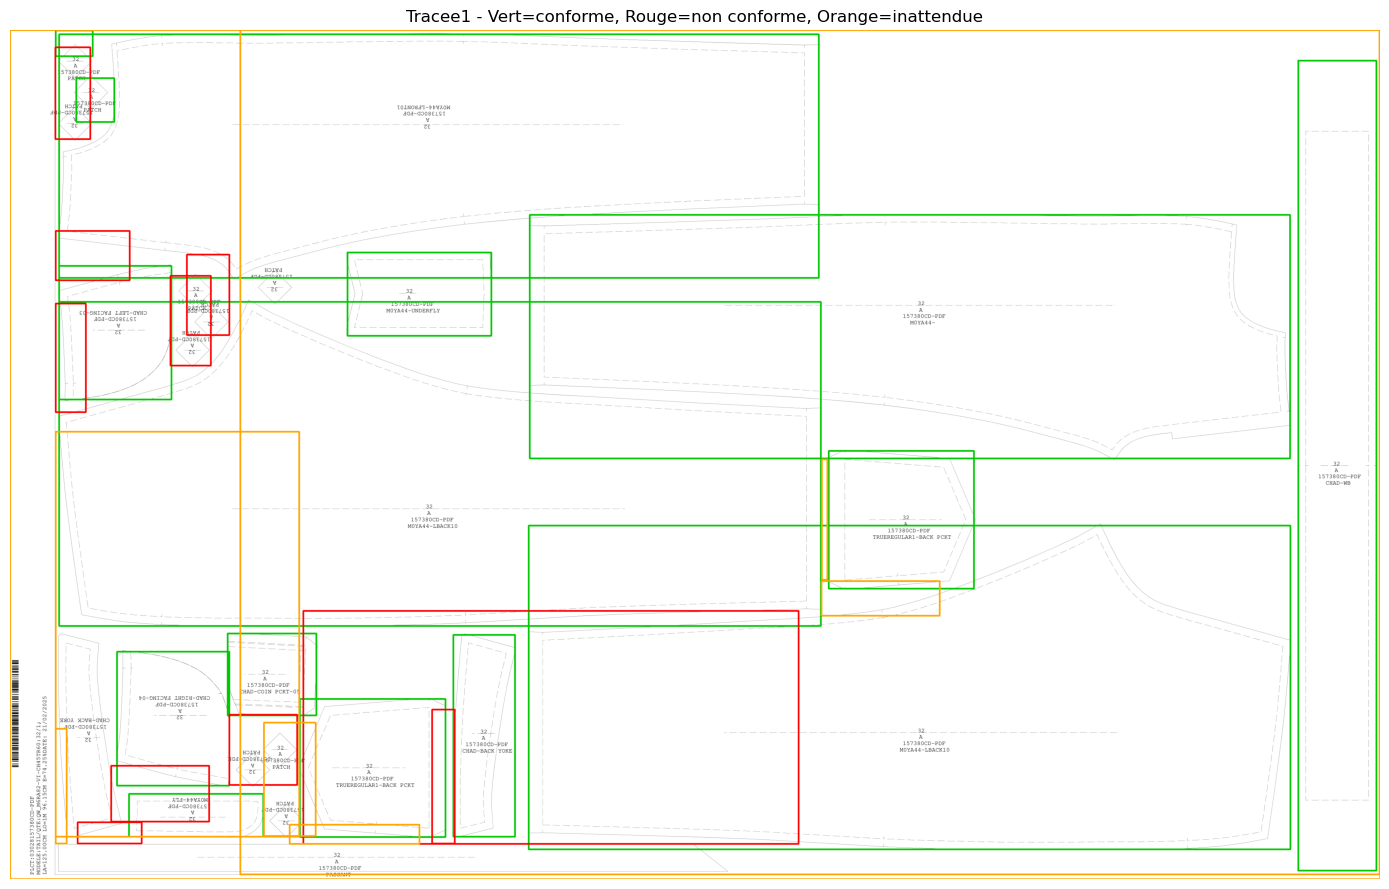


RAPPORT DE CONFORMITE - Tracee2 (modele 02110170811CD-A)
Pieces reference   : 40
  Conformes        : 28
  Non conformes    : 12
  Manquantes       : 0
Detections inattendues : 10
Taux de conformite global : 70.0%
Temps total : 5.95s


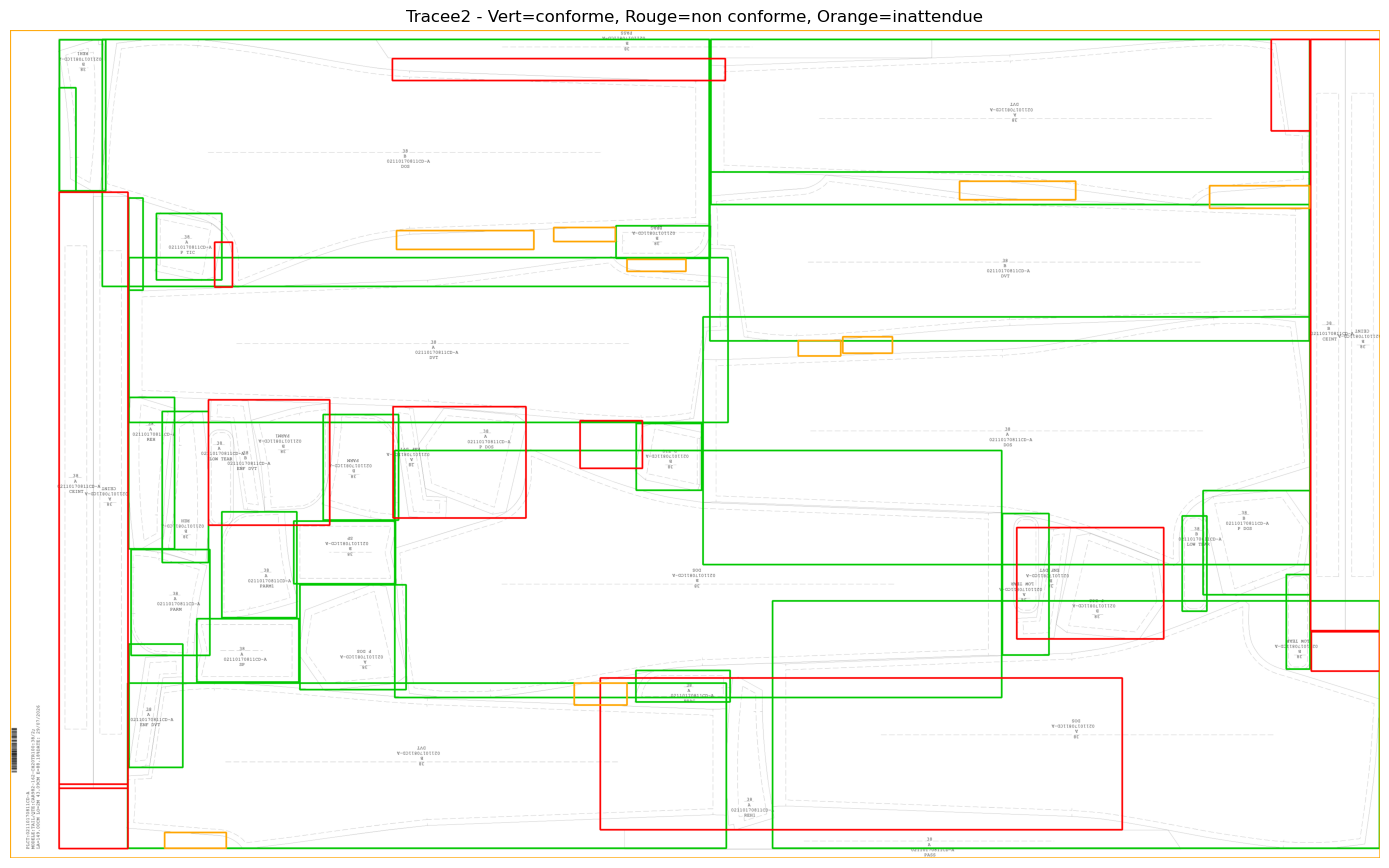


RAPPORT DE CONFORMITE - Tracee3 (modele 01461170745CD-A1)
Pieces reference   : 23
  Conformes        : 15
  Non conformes    : 8
  Manquantes       : 0
Detections inattendues : 18
Taux de conformite global : 65.2%
Temps total : 7.22s


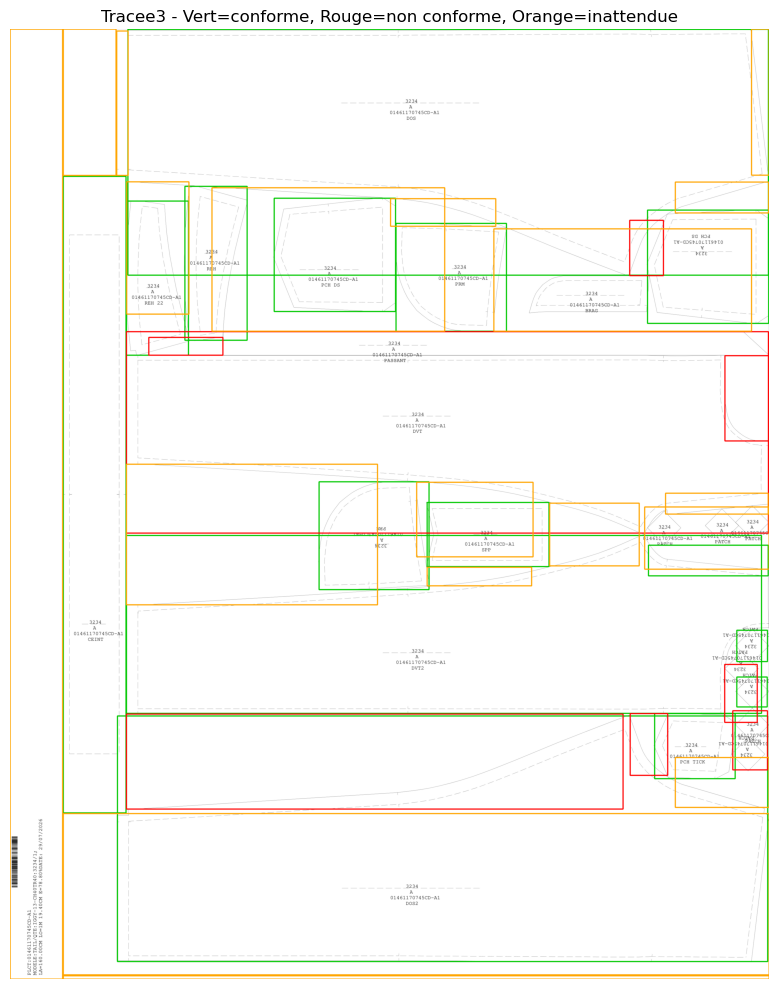


RAPPORT DE CONFORMITE - Tracee4 (modele 01110170919CD-A)
Pieces reference   : 37
  Conformes        : 28
  Non conformes    : 9
  Manquantes       : 0
Detections inattendues : 24
Taux de conformite global : 75.7%
Temps total : 9.16s


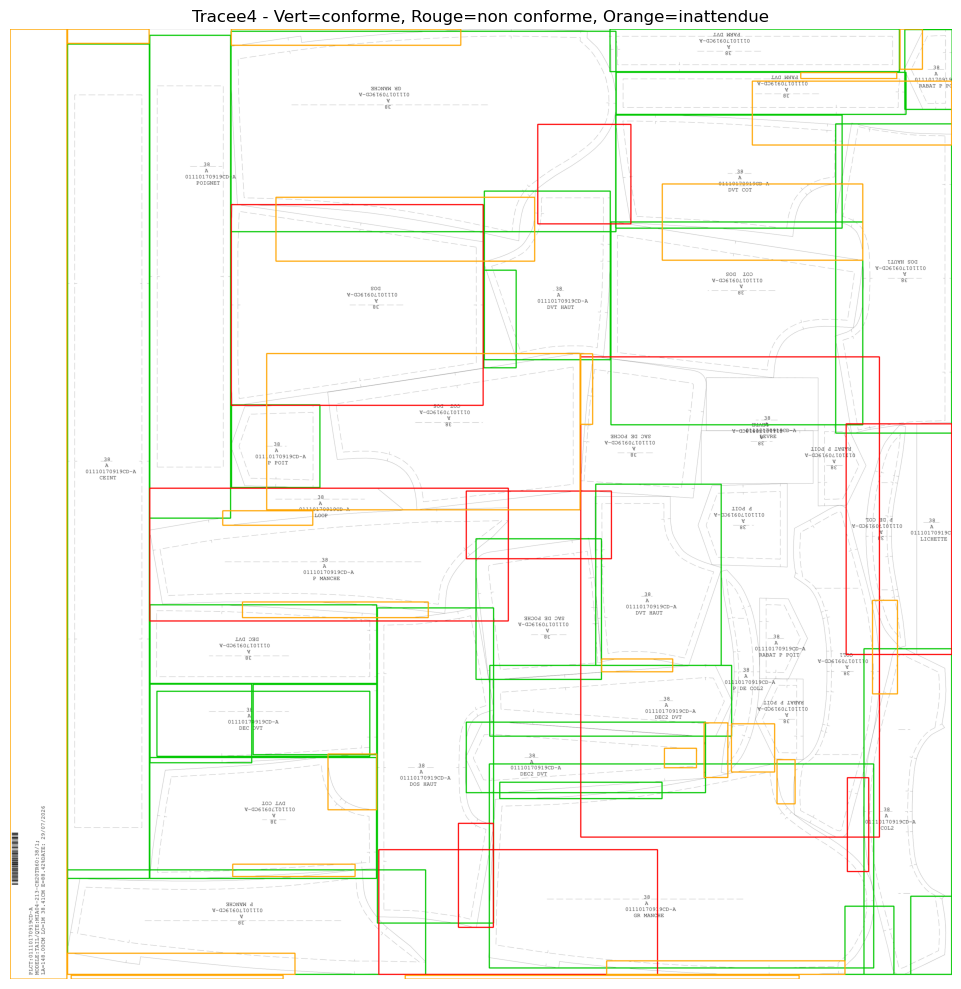


Sauvegarde dans ../data/results/pipeline_conformite_resultats.json


In [6]:
RESULTS_DIR_PATH = Path(RESULTS_DIR)
RESULTS_DIR_PATH.mkdir(parents=True, exist_ok=True)

rapports_complets = {}
for tracee in TRACEES_CONNUS:
    rapports_complets[tracee] = verifier_conformite_tracee(tracee)
    print()

with open(RESULTS_DIR_PATH / "pipeline_conformite_resultats.json", "w") as f:
    json.dump(rapports_complets, f, indent=2)

print(f"Sauvegarde dans {RESULTS_DIR}/pipeline_conformite_resultats.json")

## 5. Resume global

In [7]:
print("="*70)
print("RESUME GLOBAL - PIPELINE DE CONFORMITE")
print("="*70)
print(f"{'Trace':10s} {'Reference':>10s} {'Conformes':>10s} {'Non conf.':>10s} "
      f"{'Manquantes':>11s} {'Inattendues':>12s} {'Taux':>8s}")
for tracee, r in rapports_complets.items():
    print(f"{tracee:10s} {r['n_pieces_reference']:10d} {r['n_conformes']:10d} "
          f"{r['n_non_conformes']:10d} {r['n_manquantes']:11d} {r['n_inattendues']:12d} "
          f"{r['taux_conformite_global']*100:7.1f}%")

taux_moyen = np.mean([r['taux_conformite_global'] for r in rapports_complets.values()])
print(f"\nTaux de conformite moyen sur les 4 traces : {taux_moyen*100:.1f}%")

RESUME GLOBAL - PIPELINE DE CONFORMITE
Trace       Reference  Conformes  Non conf.  Manquantes  Inattendues     Taux
Tracee1            25         15         10           0            8    60.0%
Tracee2            40         28         12           0           10    70.0%
Tracee3            23         15          8           0           18    65.2%
Tracee4            37         28          9           0           24    75.7%

Taux de conformite moyen sur les 4 traces : 67.7%
